### Imports

In [157]:
import statistics
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.config import CONFIG
from src.preprocessing import get_waveform_transformer, get_spectrogram_transformer

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [158]:
INPUT_DIR = Path('../../data/BatvisionV2')

### Profiling the BatVision dataset

In [159]:
def run_profiling() -> None:
    durations = []
    sample_rates = Counter()
    channels = Counter()

    for audio_file in INPUT_DIR.rglob("*.wav"):
        info = torchaudio.info(audio_file)
        sample_rates[info.sample_rate] += 1
        channels[info.num_channels] += 1
        durations.append(info.num_frames / info.sample_rate)

    print(f'Number of files: {len(durations)}')
    print(f'Sample rates: {dict(sample_rates)}')
    print(f'Channels: {dict(channels)}')
    print()
    print('[Durations]')
    print(f'Min: {min(durations):.3f}s')
    print(f'Max: {max(durations):.3f}s')
    print(f'Mean: {sum(durations)/len(durations):.3f}s')
    print(f'Median: {statistics.median(durations):.3f}s')

run_profiling()

Number of files: 3120
Sample rates: {44100: 3120}
Channels: {2: 3120}

[Durations]
Min: 0.453s
Max: 0.454s
Mean: 0.454s
Median: 0.454s


### Visualising BatVision audio as Gammatone Spectrograms

STFT kernels created, time used = 0.0183 seconds
STFT filter created, time used = 0.0039 seconds
Gammatone filter created, time used = 0.0040 seconds


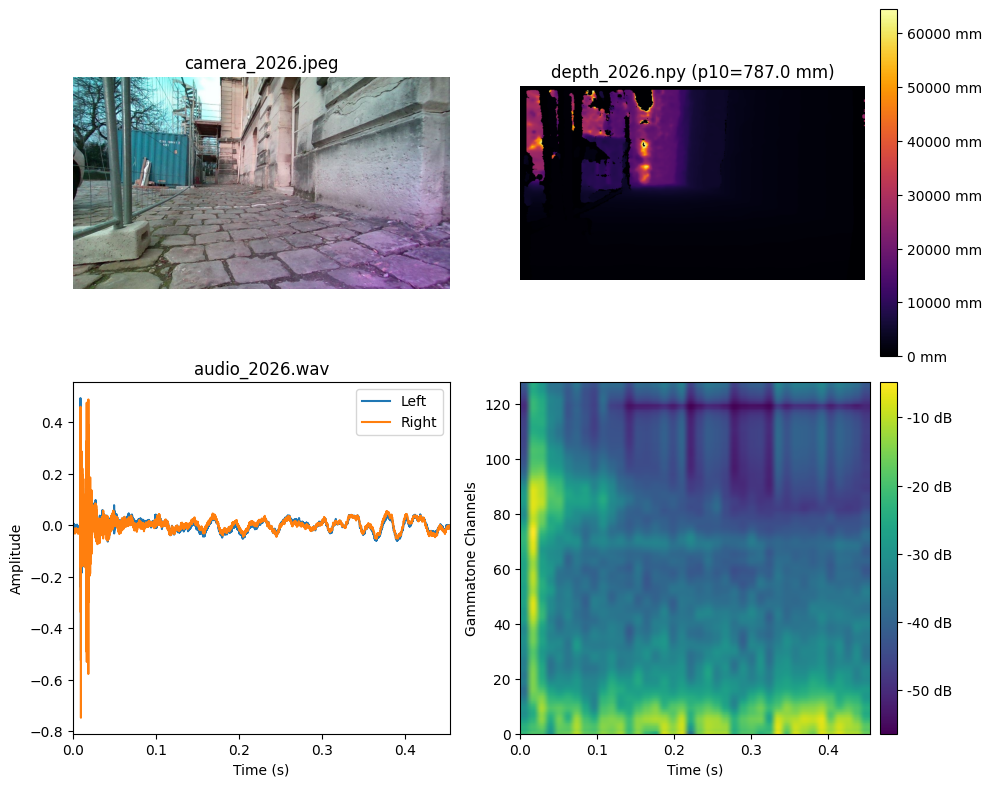

Original: 20000 samples (0.454s)
Preprocessed: 20021 samples (0.454s)


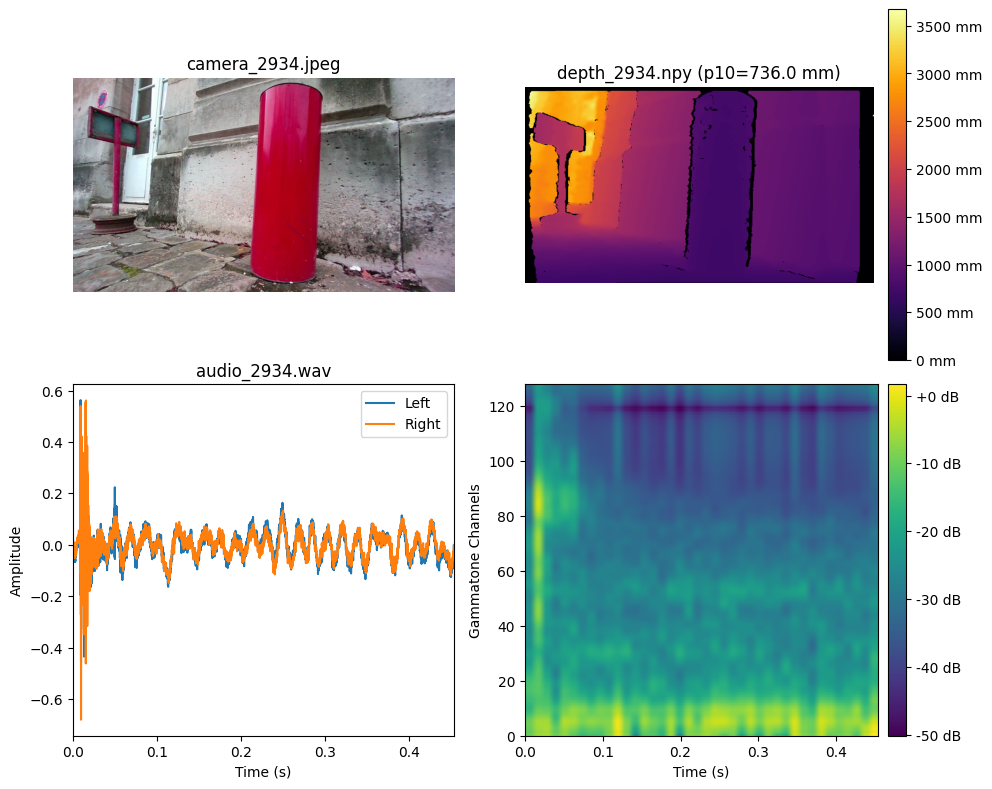

Original: 20000 samples (0.454s)
Preprocessed: 20021 samples (0.454s)


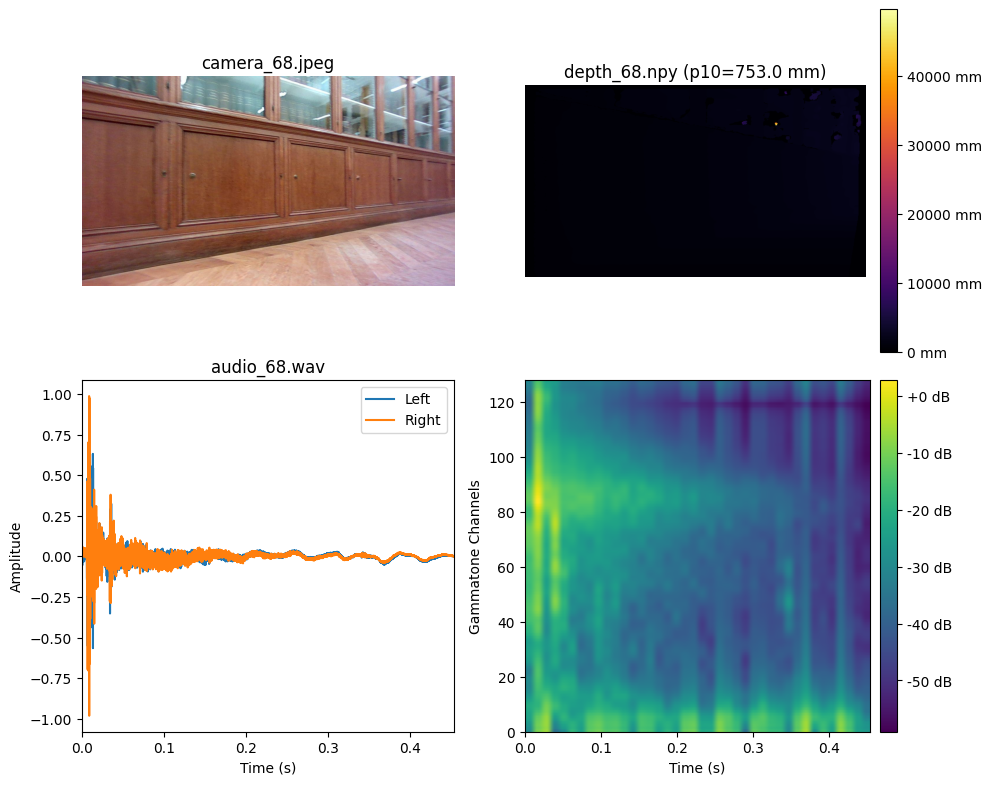

Original: 20000 samples (0.454s)
Preprocessed: 20021 samples (0.454s)


In [160]:
def get_random_sample(dir: Path) -> tuple[Path, Path, Path]:
    """Grab a random audio file, as well as the associated camera picture and depth file."""
    audio_files = list(dir.rglob('*.wav'))
    audio_path = audio_files[np.random.randint(0, len(audio_files))]
    env_dir = audio_path.parent.parent
    index = audio_path.stem.split('_')[1]
    camera_path = env_dir / 'camera' / f'camera_{index}.jpeg'
    depth_path = env_dir / 'depth' / f'depth_{index}.npy'

    return audio_path, camera_path, depth_path

def visualise_audio_data() -> None:
    config = CONFIG.batvision
    waveform_transformer = get_waveform_transformer(config)
    spectrogram_transformer = get_spectrogram_transformer(config, filterbank='gammatone')

    for i in range(3):
        audio_path, camera_path, depth_path = get_random_sample(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(audio_path)
        new_waveform = waveform_transformer(raw_waveform)
        gammatone_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / config.target_sample_rate

        # Plotting
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))

        # Camera
        camera_img = plt.imread(camera_path)
        axes[0, 0].imshow(camera_img)
        axes[0, 0].set_title(camera_path.name)
        axes[0, 0].axis('off')

        # Depth
        depth_map = np.load(depth_path).astype(float)
        im_depth = axes[0, 1].imshow(depth_map, cmap='inferno')
        valid = depth_map[depth_map > 0]
        p10 = np.percentile(valid, 10)
        axes[0, 1].set_title(f'{depth_path.name} (p10={p10} mm)')
        axes[0, 1].axis('off')
        fig.colorbar(im_depth, ax=axes[0, 1], format='%.0f mm', fraction=0.046, pad=0.04)

        # Waveform
        time_axis = np.linspace(0, new_duration, new_samples)
        axes[1, 0].plot(time_axis, new_waveform[0].numpy(), label='Left')
        axes[1, 0].plot(time_axis, new_waveform[1].numpy(), label='Right')
        axes[1, 0].set_title(audio_path.name)
        axes[1, 0].set_xlim(0, new_duration)
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_ylabel('Amplitude')
        axes[1, 0].legend()

        # Gammatone Spectrogram
        img = axes[1, 1].imshow(
            gammatone_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='viridis',
            extent=[0, new_duration, 0, config.n_bins],
        )
        axes[1, 1].set_ylabel('Gammatone Channels')
        axes[1, 1].set_xlabel('Time (s)')
        div2 = make_axes_locatable(axes[1, 1])
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

        display(Audio(data=new_waveform, rate=config.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.3f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.3f}s)')

visualise_audio_data()

### Plot p10 depth distribution across all samples

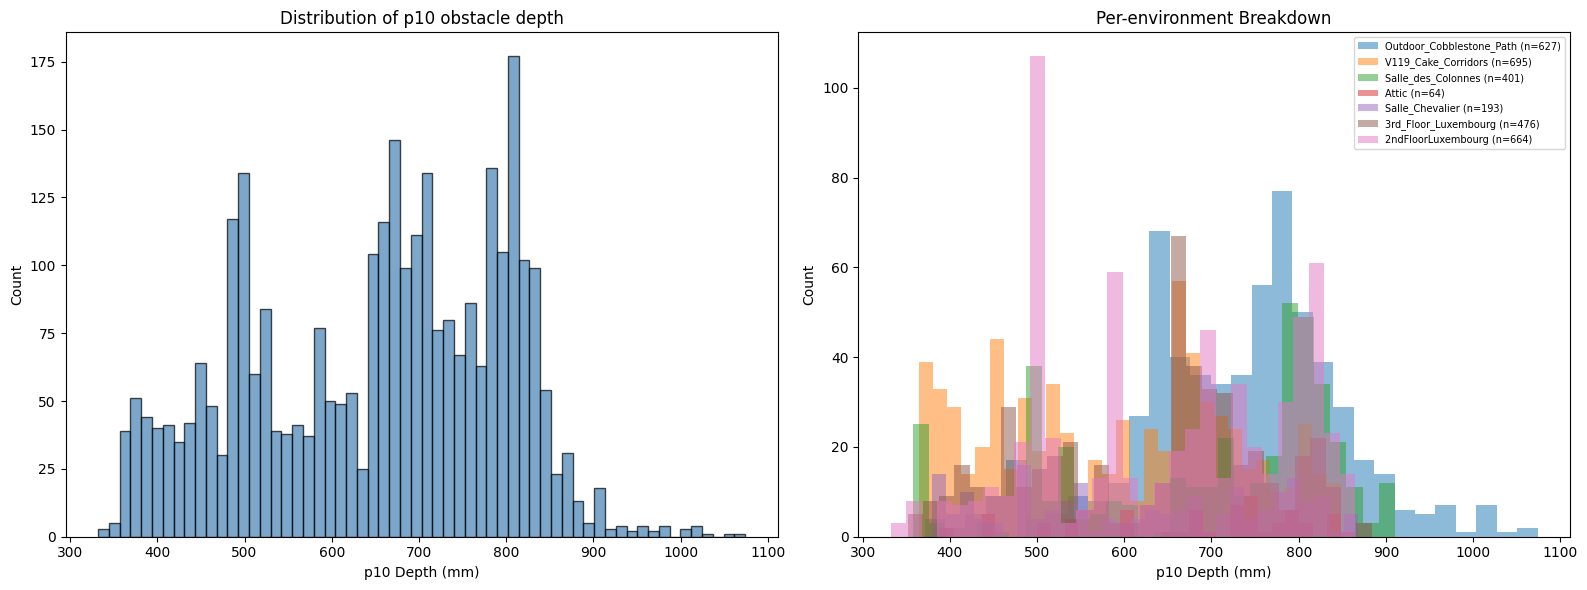

[p10 Stats]
Min: 332mm
Max: 1074mm
Mean: 653mm
Std: 144mm


In [161]:
def plot_p10_depth_distribution() -> None:
    envs = Counter()
    p10_depths = []

    for env_dir in INPUT_DIR.iterdir():
        if not env_dir.is_dir():
            continue

        for depth_file in list(env_dir.rglob('*.npy')):
            depth_map = np.load(depth_file)
            valid = depth_map[depth_map > 0]
            p10_depths.append(np.percentile(valid, 10))

            envs[env_dir.name] += 1

    p10_depths = np.array(p10_depths)

    # Plot graph
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Overall distribution
    ax1.hist(p10_depths, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.set_title('Distribution of p10 obstacle depth')
    ax1.set_xlabel('p10 Depth (mm)')
    ax1.set_ylabel('Count')

    # Per-environment overlay
    for environment, n in envs.items():
        env_depths = [d for d, l in zip(p10_depths, env_labels) if l == environment]
        ax2.hist(env_depths, bins=30, alpha=0.5, label=f'{environment} (n={n})')
    ax2.set_title('Per-environment Breakdown')
    ax2.set_xlabel('p10 Depth (mm)')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    print('[p10 Stats]')
    print(f'Min: {p10_depths.min():.0f}mm')
    print(f'Max: {p10_depths.max():.0f}mm')
    print(f'Mean: {p10_depths.mean():.0f}mm')
    print(f'Std: {p10_depths.std():.0f}mm')

plot_p10_depth_distribution()